In [2]:
# Importing the necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Reading the CSV files for the World Happiness Report from 2015 to 2019
df = pd.read_csv("./WorldHappinessReport/2015.csv")
df = pd.read_csv("./WorldHappinessReport/2016.csv")
df = pd.read_csv("./WorldHappinessReport/2017.csv")
df = pd.read_csv("./WorldHappinessReport/2018.csv")
df = pd.read_csv("./WorldHappinessReport/2019.csv")
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [5]:

# rows and columns
df.shape

(156, 9)

In [6]:

# column information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


In [7]:


# statistics of numerical columns
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


# DATA PREPROCESSING



In [8]:
# Column names

df.columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='str')

In [9]:
# Cleaning the column names by stripping whitespace, converting to lowercase, and replacing spaces with underscores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)

df.head()

,overall_rank,country_or_region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [10]:
# Checking for missing values in the dataset
df.isnull().sum()

overall_rank                    0
country_or_region               0
score                           0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64

In [11]:
# Filling missing values in the dataset with the mean of each column

df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

,overall_rank,country_or_region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [ ]:
# Checking for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
#  Removing duplicate rows from the dataset
df.drop_duplicates(
    inplace=True
)

In [ ]:
# Inspecting the dataset after cleaning

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   overall_rank                  156 non-null    int64  
 1   country_or_region             156 non-null    str    
 2   score                         156 non-null    float64
 3   gdp_per_capita                156 non-null    float64
 4   social_support                156 non-null    float64
 5   healthy_life_expectancy       156 non-null    float64
 6   freedom_to_make_life_choices  156 non-null    float64
 7   generosity                    156 non-null    float64
 8   perceptions_of_corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


In [12]:
# %%

score_table = df[["country_or_region", "score"]]

score_table.head(10)

,country_or_region,score
0,Finland,7.769
1,Denmark,7.600
2,Norway,7.554
3,Iceland,7.494
4,Netherlands,7.488
5,Switzerland,7.480
6,Sweden,7.343
7,New Zealand,7.307
8,Canada,7.278
9,Austria,7.246


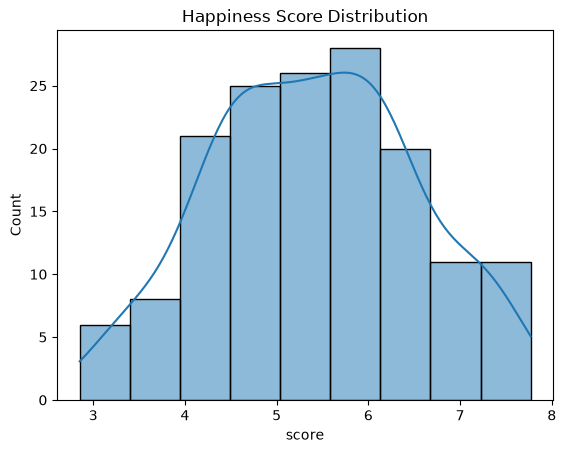

In [ ]:
# Happiness Score Distribution
sns.histplot(
    df["score"],
    kde=True
)

plt.title(
"Happiness Score Distribution"
)

plt.show()

In [13]:
# %%

gdp_table = df[
    [
        "country_or_region",
        "gdp_per_capita"
    ]
]

gdp_table.head(10)

,country_or_region,gdp_per_capita
0,Finland,1.340
1,Denmark,1.383
2,Norway,1.488
3,Iceland,1.380
4,Netherlands,1.396
5,Switzerland,1.452
6,Sweden,1.387
7,New Zealand,1.303
8,Canada,1.365
9,Austria,1.376


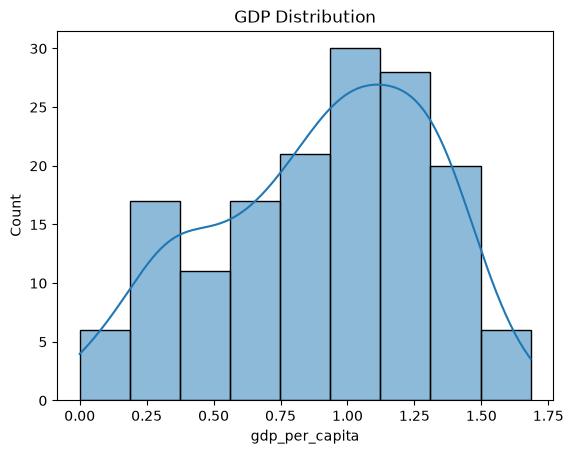

In [ ]:
# GDP Distribution
sns.histplot(
    df["gdp_per_capita"],
    kde=True
)

plt.title(
"GDP Distribution"
)

plt.show()

In [14]:
# %%

top10 = df.nlargest(
    10,
    "score"
)


top10[
    [
        "country_or_region",
        "score"
    ]
]

,country_or_region,score
0,Finland,7.769
1,Denmark,7.600
2,Norway,7.554
3,Iceland,7.494
4,Netherlands,7.488
5,Switzerland,7.480
6,Sweden,7.343
7,New Zealand,7.307
8,Canada,7.278
9,Austria,7.246


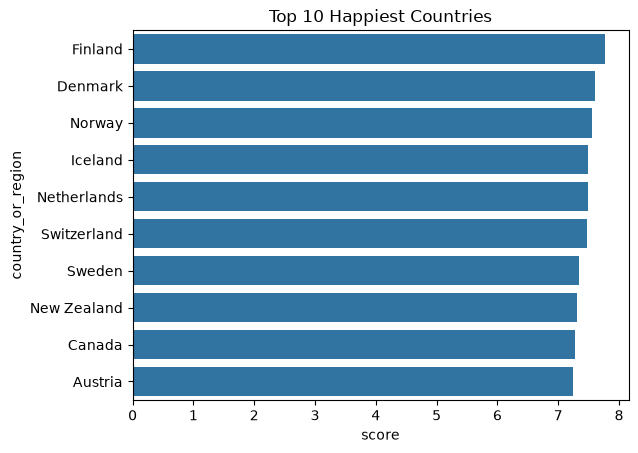

In [ ]:
# Happiness Score vs Country/Region
top10 = df.nlargest(
    10,
    "score"
)


sns.barplot(
    x="score",
    y="country_or_region",
    data=top10
)


plt.title(
"Top 10 Happiest Countries"
)

plt.show()

# BIVARIATE ANALYSIS

In [15]:
# %%

gdp_happiness = df[
    [
        "country_or_region",
        "gdp_per_capita",
        "score"
    ]
]


gdp_happiness.head(10)

,country_or_region,gdp_per_capita,score
0,Finland,1.340,7.769
1,Denmark,1.383,7.600
2,Norway,1.488,7.554
3,Iceland,1.380,7.494
4,Netherlands,1.396,7.488
5,Switzerland,1.452,7.480
6,Sweden,1.387,7.343
7,New Zealand,1.303,7.307
8,Canada,1.365,7.278
9,Austria,1.376,7.246


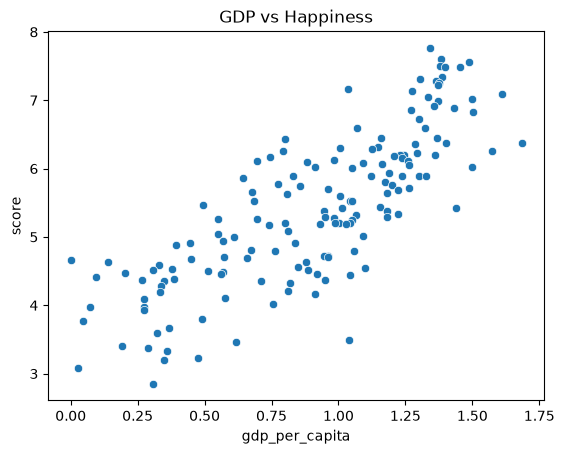

In [ ]:
# GDP vs Happiness score

sns.scatterplot(
    x="gdp_per_capita",
    y="score",
    data=df
)


plt.title(
"GDP vs Happiness"
)


plt.show()

In [16]:
# %%

health_table = df[
    [
        "country_or_region",
        "healthy_life_expectancy",
        "score"
    ]
]


health_table.head(10)

,country_or_region,healthy_life_expectancy,score
0,Finland,0.986,7.769
1,Denmark,0.996,7.600
2,Norway,1.028,7.554
3,Iceland,1.026,7.494
4,Netherlands,0.999,7.488
5,Switzerland,1.052,7.480
6,Sweden,1.009,7.343
7,New Zealand,1.026,7.307
8,Canada,1.039,7.278
9,Austria,1.016,7.246


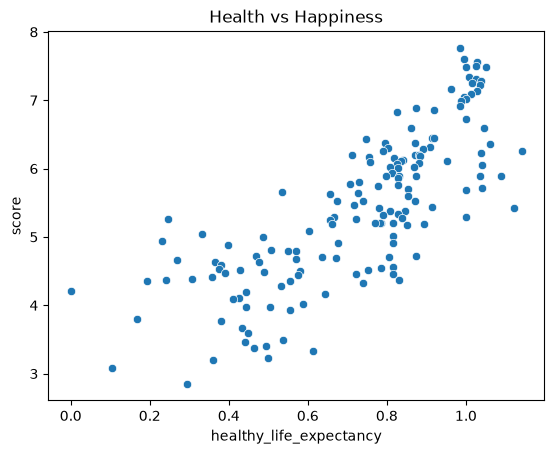

In [ ]:
# Health vs Happiness

sns.scatterplot(
    x="healthy_life_expectancy",
    y="score",
    data=df
)


plt.title(
"Health vs Happiness"
)

plt.show()

In [17]:
# %%

freedom_table = df[
    [
        "country_or_region",
        "freedom_to_make_life_choices",
        "score"
    ]
]


freedom_table.head(10)

,country_or_region,freedom_to_make_life_choices,score
0,Finland,0.596,7.769
1,Denmark,0.592,7.600
2,Norway,0.603,7.554
3,Iceland,0.591,7.494
4,Netherlands,0.557,7.488
5,Switzerland,0.572,7.480
6,Sweden,0.574,7.343
7,New Zealand,0.585,7.307
8,Canada,0.584,7.278
9,Austria,0.532,7.246


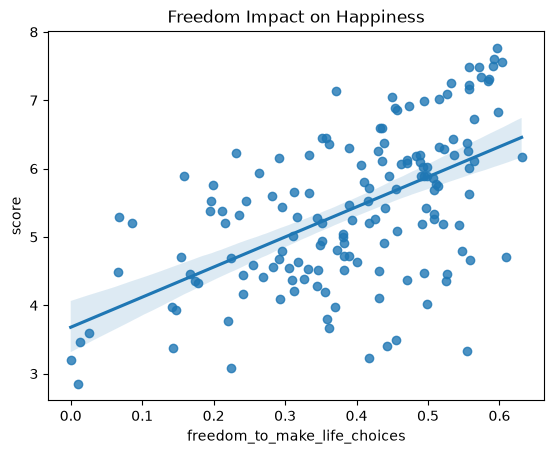

In [ ]:
# Freedom Impact on Happiness
sns.regplot(
    x="freedom_to_make_life_choices",
    y="score",
    data=df
)


plt.title(
"Freedom Impact on Happiness"
)


plt.show()

# MULTIVARIATE ANALYSIS

In [18]:
# %%

correlation_table = df.corr(
    numeric_only=True
)


correlation_table

,overall_rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
overall_rank,1.000000,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
score,-0.989096,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
gdp_per_capita,-0.801947,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
social_support,-0.767465,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
healthy_life_expectancy,-0.787411,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
freedom_to_make_life_choices,-0.546606,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
generosity,-0.047993,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
perceptions_of_corruption,-0.351959,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


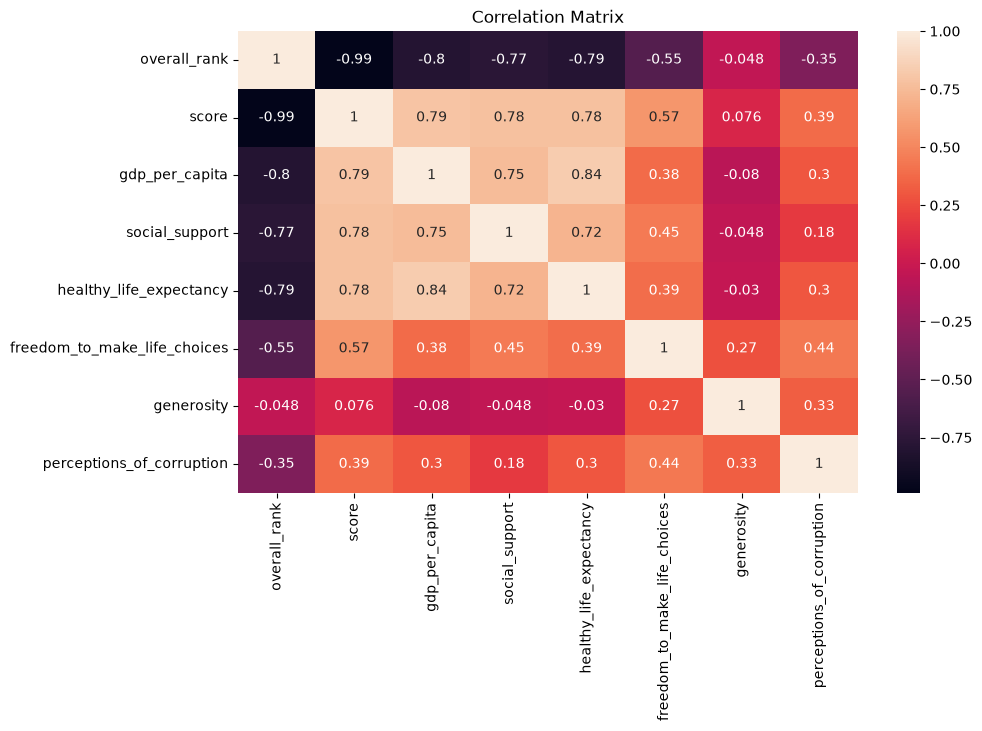

In [ ]:
# Correlation Matrix

plt.figure(figsize=(10,6))


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)


plt.title(
"Correlation Matrix"
)


plt.show()

In [19]:
# %%

pairplot_table = df[
    [
        "score",
        "gdp_per_capita",
        "social_support",
        "healthy_life_expectancy",
        "freedom_to_make_life_choices"
    ]
]


pairplot_table.head()

,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices
0,7.769,1.340,1.587,0.986,0.596
1,7.600,1.383,1.573,0.996,0.592
2,7.554,1.488,1.582,1.028,0.603
3,7.494,1.380,1.624,1.026,0.591
4,7.488,1.396,1.522,0.999,0.557


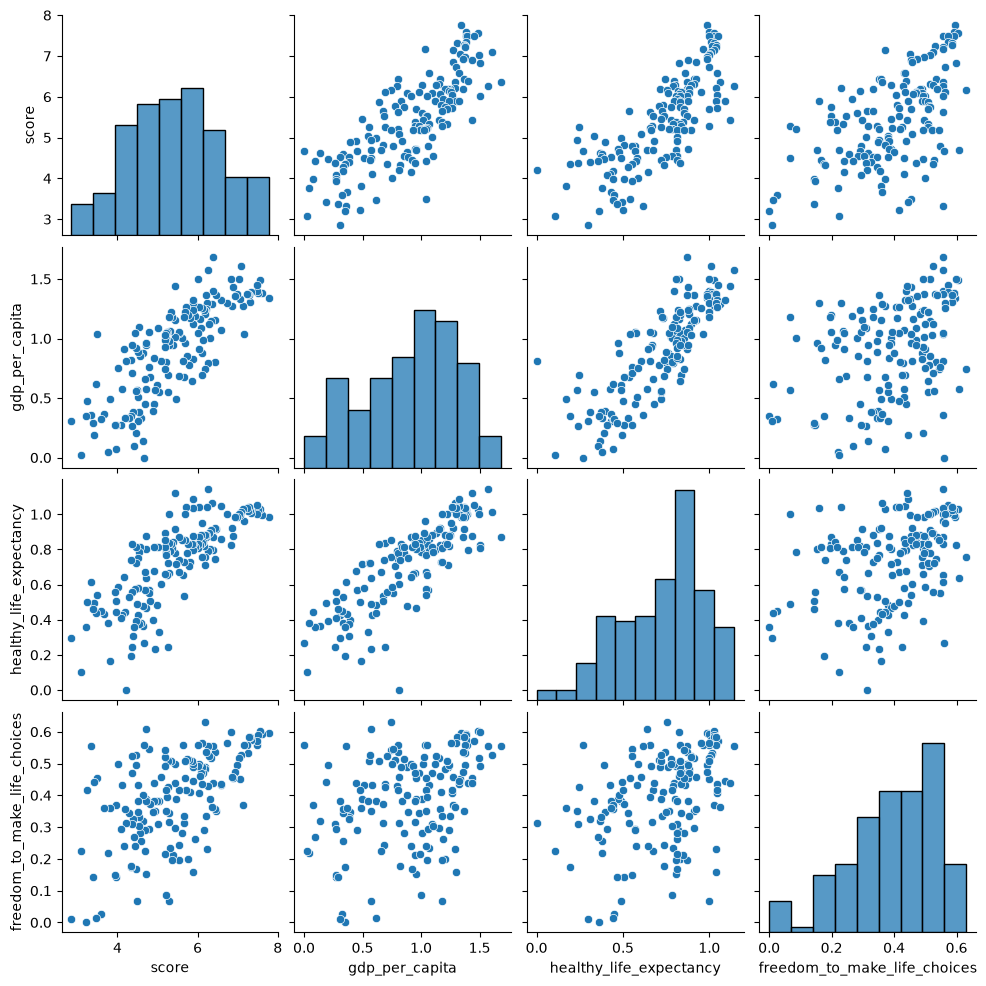

In [ ]:
# Pairplot of selected features
sns.pairplot(
    df[
        [
            "score",
            "gdp_per_capita",
            "healthy_life_expectancy",
            "freedom_to_make_life_choices"
        ]
    ]
)


plt.show()

In [20]:
# %%

multi_table = df[
    [
        "country_or_region",
        "score",
        "gdp_per_capita",
        "healthy_life_expectancy"
    ]
]


multi_table.head(10)

,country_or_region,score,gdp_per_capita,healthy_life_expectancy
0,Finland,7.769,1.340,0.986
1,Denmark,7.600,1.383,0.996
2,Norway,7.554,1.488,1.028
3,Iceland,7.494,1.380,1.026
4,Netherlands,7.488,1.396,0.999
5,Switzerland,7.480,1.452,1.052
6,Sweden,7.343,1.387,1.009
7,New Zealand,7.307,1.303,1.026
8,Canada,7.278,1.365,1.039
9,Austria,7.246,1.376,1.016


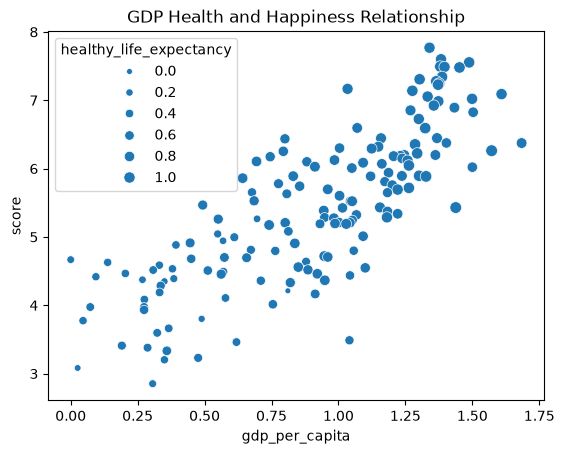

In [ ]:
# GDP Health and Happiness Relationship

sns.scatterplot(
    x="gdp_per_capita",
    y="score",
    size="healthy_life_expectancy",
    data=df
)


plt.title(
"GDP Health and Happiness Relationship"
)


plt.show()